# Which segmentation model is best?

Cellpose-style 2D segmenters run per z-plane and stitch the results through z.
A mask confined to one or two slices is usually not a cell -- it is a fragment
or a spurious detection, and your pipeline already throws these away with
`filter_params.min_z = 3`.

So the metric here is the **thin rate**: the share of masks occupying at most
`THIN_MAX_SLICES` z-slices. **Lower is better.** It reads directly as *the
fraction of detections the `min_z` filter discards* -- work the model did that
was thrown away.

This notebook scores every run under a directory and ranks the models on it.

**The volumes are never loaded into memory.** `virtualizarr` + `virtual_tiff`
parse each multi-page TIFF's IFDs into a zarr store whose chunks point straight
at the TIFF's tile byte-ranges, and the analysis streams over those in
chunk-aligned blocks -- so peak memory is set by the read size, not the image
size.

## Setup

Point `SEGMENTATION_ROOT` at your own output tree.

`MODEL_LEVELS` names the directory levels that identify a model, and
`level_names` names every level below the root. Adjust both to your layout --
if the model is only recorded in each run's `meta.json` rather than in the
path, read those into a column and use it as the grouping key instead.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap

from zspan import (
    BLUES,
    CATEGORICAL,
    add_variant_column,
    apply_theme,
    check_z_span,
    open_mask_volume,
    plot_variant_summary,
    scan_segmentations,
)
from zspan.plotting import GRID, INK, INK_SECONDARY, SURFACE

apply_theme()
pd.set_option("display.width", 160)

# Point this at your own segmentation output tree.
SEGMENTATION_ROOT = Path("data/segmentations/cpdino")

LEVEL_NAMES = ("preprocessing", "model", "region", "fov")
MODEL_LEVELS = ["preprocessing", "model"]   # joined into a single `variant` label

# A mask this thin or thinner counts as a fragment.  Keep it in step with
# cellpose's `min_z`: min_z=3 discards anything under 3 slices, so 2 here.
THIN_MAX_SLICES = 2

SEGMENTATION_ROOT

PosixPath('data/segmentations/cpdino')

## Scan and score

One pass over every volume, then the thin rate per volume and per model.

In [2]:
result = scan_segmentations(
    SEGMENTATION_ROOT,
    pattern="**/masks.tif",
    level_names=LEVEL_NAMES,
    progress=lambda done, total, path: (
        print(f"  scored {done}/{total} volumes")
        if done % max(1, total // 4) == 0 or done == total
        else None
    ),
)
if result.failures:
    print(f"{len(result.failures)} volume(s) failed to read:")
    for path, error in result.failures:
        print(f"  {path}: {error!r}")

summary = add_variant_column(result.summary, MODEL_LEVELS)
labels = add_variant_column(result.labels, MODEL_LEVELS)

# n_planes counts slices actually occupied, which is what a min_z filter tests.
# (It equals z_span unless a mask has a gap in z -- see n_with_z_gaps.)
labels["is_thin"] = labels["n_planes"] <= THIN_MAX_SLICES
summary = summary.merge(
    labels.groupby("relpath")["is_thin"].mean().mul(100).rename("thin_rate"),
    on="relpath",
)

# Best first, and reused by every figure so a model keeps its position.
model_order = summary.groupby("variant")["thin_rate"].mean().sort_values().index.tolist()

if summary["n_z"].nunique() > 1:
    print(
        f"WARNING: stacks differ in depth {sorted(summary['n_z'].unique())}. "
        "A fixed slice threshold is not comparable across them -- consider a "
        "fraction of stack depth instead."
    )
if len(model_order) < 2:
    print(f"NOTE: only one model present ({model_order[0]}); comparisons need at least two.")

print()
print(f"{len(summary)} volumes, {len(labels):,} masks, {len(model_order)} model(s)")
model_order

  scored 12/48 volumes


  scored 24/48 volumes


  scored 36/48 volumes


  scored 48/48 volumes

48 volumes, 14,101 masks, 4 model(s)


['decon / CPSAM', 'decon / CBDN', 'raw / CPSAM', 'raw / CBDN']

## A. Which model wins

Ranked by thin rate, best at the top. Each dot is one FOV; the bar is the mean.

The dots are the point. With only a handful of FOVs per model, **a gap smaller
than the within-model spread is not a result** -- if the dot clouds overlap,
the ranking is not yet decided and you need more FOVs, not a better plot.

(0.0, 55.30927835051546)

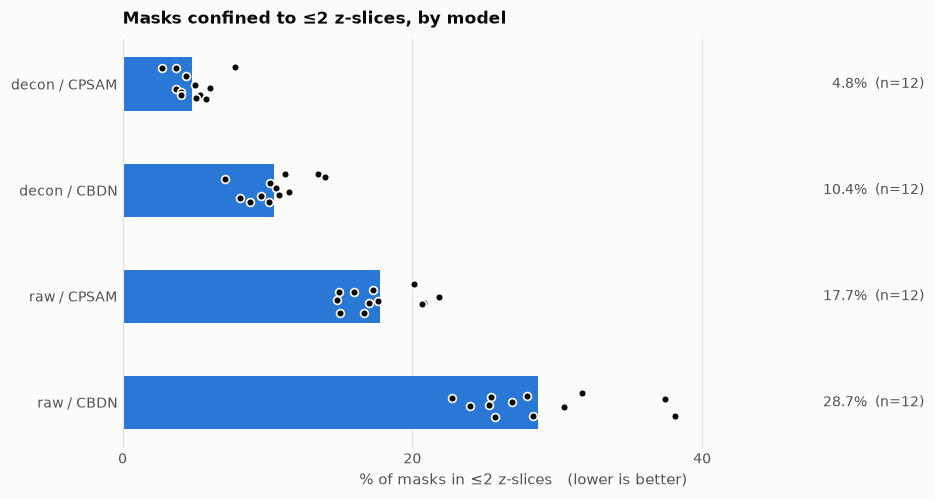

In [3]:
fig = plot_variant_summary(
    summary,
    group="variant",
    value="thin_rate",
    title=f"Masks confined to ≤{THIN_MAX_SLICES} z-slices, by model",
    value_label=f"% of masks in ≤{THIN_MAX_SLICES} z-slices   (lower is better)",
)
ax = fig.axes[0]
ax.invert_yaxis()   # plot_variant_summary sorts ascending; put the best on top

# That function floors the x-axis at 100%, which fits a 0-100 metric but wastes
# most of the width when the thin rate tops out well below it.  Rescale to the
# data, moving the value labels (the only Text artists) with it.
x_max = summary["thin_rate"].max() * 1.45
for text in ax.texts:
    text.set_x(x_max)
ax.set_xlim(0, x_max)

## D. Is the win real, or just fewer detections?

A model can post a low thin rate simply by **not finding the faint cells** --
skip the marginal detections and the fragment tail disappears along with them.
Rate alone cannot tell "cleaner" from "more conservative".

So plot yield against quality. Each point is one FOV; the ringed marker is the
model's centroid. **Better is bottom-right**: many masks, few fragments. A model
sitting bottom-*left* is winning on the metric by doing less work.

Check the x-range before reading a story into it -- a scatter auto-scales, so a
narrow yield spread gets stretched across the full width and can look like a
gradient when it is a couple of percent.

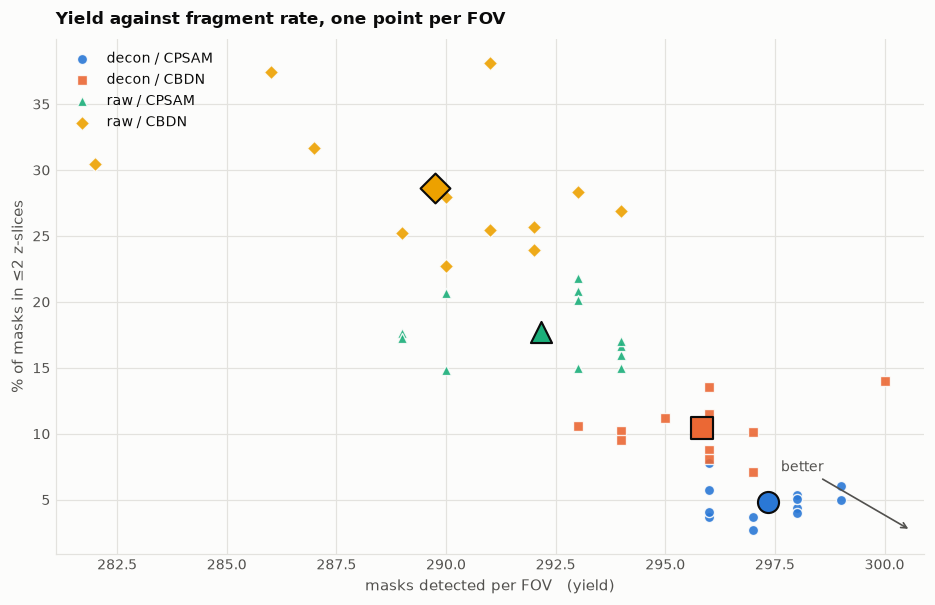

In [4]:
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*"]

fig, ax = plt.subplots(figsize=(8.6, 5.6))
for i, name in enumerate(model_order):
    part = summary[summary["variant"] == name]
    # hue + shape together: a scatter compares every pair at once, so shape
    # carries identity past the point where hue alone stays distinguishable
    ax.scatter(
        part["n_labels"], part["thin_rate"],
        s=44, marker=MARKERS[i % len(MARKERS)],
        facecolor=CATEGORICAL[i % len(CATEGORICAL)],
        edgecolor=SURFACE, linewidth=0.9, alpha=0.9, zorder=3, label=name,
    )
    ax.scatter(
        part["n_labels"].mean(), part["thin_rate"].mean(),
        s=190, marker=MARKERS[i % len(MARKERS)],
        facecolor=CATEGORICAL[i % len(CATEGORICAL)],
        edgecolor=INK, linewidth=1.4, zorder=4,
    )

ax.set_xlabel("masks detected per FOV   (yield)")
ax.set_ylabel(f"% of masks in ≤{THIN_MAX_SLICES} z-slices")
ax.set_title("Yield against fragment rate, one point per FOV", pad=10, loc="left")
ax.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(length=0)
for side in ("left", "bottom"):
    ax.spines[side].set_color(GRID)
ax.annotate(
    "better", xy=(0.985, 0.045), xytext=(0.86, 0.16), xycoords="axes fraction",
    textcoords="axes fraction", ha="center", fontsize=9, color=INK_SECONDARY,
    arrowprops=dict(arrowstyle="->", color=INK_SECONDARY, lw=1.1),
)
ax.legend(loc="upper left", ncols=1)
fig.tight_layout()

## B. Where the difference lives

The thin rate is one number off a whole distribution. This is the distribution:
each row is a model's masks split by thickness, normalised to 100%.

Thickness is an **ordered** quantity, so it gets one hue light-to-dark rather
than a categorical set -- the fragments are the pale block at the left edge, and
"which model has fewest" is the width of that block. Rows keep the ranking from
A, so the pale blocks should shrink as you read down.

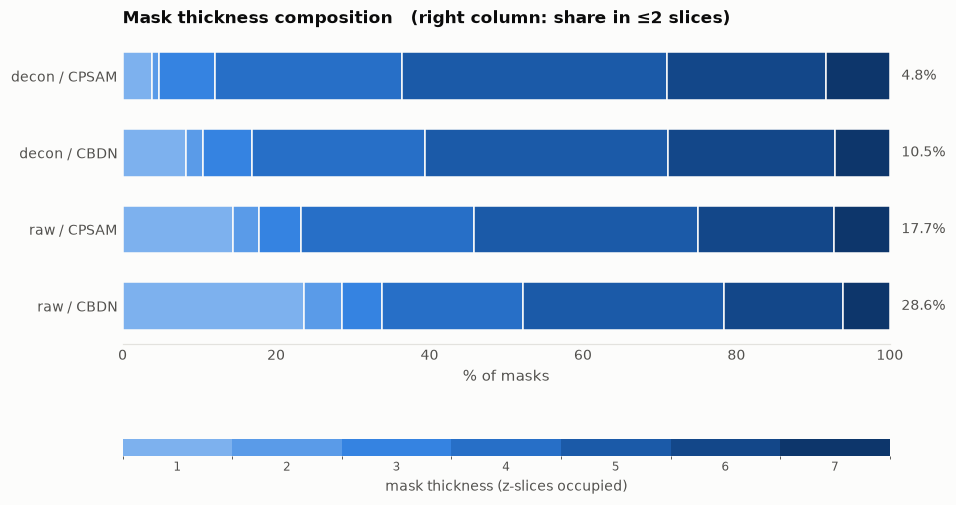

In [5]:
n_z = int(summary["n_z"].max())
thickness = np.arange(1, n_z + 1)

composition = (
    labels.groupby(["variant", "n_planes"]).size()
    .unstack(fill_value=0)
    .reindex(columns=thickness, fill_value=0)
    .reindex(model_order)
)
composition = 100 * composition.div(composition.sum(axis=1), axis=0)

# Start above the palest steps: an ordinal ramp must stay distinguishable from
# the page, unlike a continuous one where "near zero" may recede into it.
colours = BLUES(np.linspace(0.28, 1.0, len(thickness)))

fig, ax = plt.subplots(figsize=(9.0, 0.62 * len(model_order) + 2.6))
positions = np.arange(len(model_order))
left = np.zeros(len(model_order))
for j, n_slices in enumerate(thickness):
    widths = composition[n_slices].to_numpy()
    ax.barh(
        positions, widths, left=left, height=0.62, color=colours[j],
        edgecolor=SURFACE, linewidth=1.0, zorder=2,   # gap keeps segments apart
    )
    left += widths

for i, name in enumerate(model_order):
    thin_pct = composition.loc[name, composition.columns <= THIN_MAX_SLICES].sum()
    ax.text(101.5, i, f"{thin_pct:.1f}%", va="center", ha="left",
            fontsize=9, color=INK_SECONDARY)

ax.set_yticks(positions, model_order)
ax.set_xlim(0, 100)
ax.set_xlabel("% of masks")
ax.set_title(
    f"Mask thickness composition   (right column: share in ≤{THIN_MAX_SLICES} slices)",
    pad=10, loc="left",
)
ax.invert_yaxis()          # best model on top, matching A
ax.tick_params(length=0)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(GRID)

bar = fig.colorbar(
    mpl.cm.ScalarMappable(
        cmap=ListedColormap(colours),
        norm=BoundaryNorm(np.arange(0.5, len(thickness) + 1.5), len(thickness)),
    ),
    ax=ax, orientation="horizontal", ticks=thickness,
    fraction=0.07, pad=0.22, aspect=44,
)
bar.set_label("mask thickness (z-slices occupied)", color=INK_SECONDARY, fontsize=9)
bar.outline.set_visible(False)
bar.ax.tick_params(length=0, labelsize=8)

### The numbers

Shipped next to the figures on purpose: some palette steps sit below 3:1
contrast on a light background, so the table is what keeps the comparison
readable for everyone.

`n_with_z_gaps` counts masks whose bounding box spans more slices than they
occupy -- a mask that appears, disappears and returns. Those are stitching
errors rather than fragments, and they inflate `z_span` without inflating
`n_planes`, which is why the thin rate is computed on `n_planes`.

In [6]:
model_table = (
    summary.groupby("variant")
    .agg(
        fovs=("n_labels", "size"),
        masks=("n_labels", "sum"),
        masks_per_fov=("n_labels", "mean"),
        thin_rate=("thin_rate", "mean"),
        thin_rate_min=("thin_rate", "min"),
        thin_rate_max=("thin_rate", "max"),
        mean_z_span=("mean_z_span", "mean"),
        with_z_gaps=("n_with_z_gaps", "sum"),
    )
    .reindex(model_order)
    .round(2)
)
model_table

,fovs,masks,masks_per_fov,thin_rate,thin_rate_min,thin_rate_max,mean_z_span,with_z_gaps
variant,,,,,,,,
decon / CPSAM,12,3568,297.33,4.79,2.69,7.77,4.80,5
decon / CBDN,12,3550,295.83,10.45,7.07,14.00,4.62,6
raw / CPSAM,12,3506,292.17,17.74,14.83,21.84,4.31,4
raw / CBDN,12,3477,289.75,28.67,22.76,38.14,3.90,4


## Looking at one volume

`open_mask_volume` gives a lazy `(z, y, x)` handle. `chunks` reports the TIFF's
own tile or strip geometry; reads are batched to `target_bytes` on top of that,
because one chunk per read is dominated by zarr's per-request overhead.

In [7]:
worst = Path(summary.nlargest(1, "thin_rate")["path"].iloc[0])
volume = open_mask_volume(worst)

print(volume)
print(f"  native chunk {volume.chunks} -> batched read {volume.read_block_shape()}")
print(f"  full volume would be {volume.nbytes / 1e6:.1f} MB in memory")

z_table = check_z_span(volume)
fragments = z_table[z_table["n_planes"] <= THIN_MAX_SLICES]
print(f"  {len(fragments)} of {len(z_table)} masks are fragments "
      f"({100 * len(fragments) / len(z_table):.1f}%)")
fragments.head()

MaskVolume('masks.tif', shape=(7, 512, 512), chunks=(1, 128, 128), dtype=uint16)
  native chunk (1, 128, 128) -> batched read (512, 512)
  full volume would be 3.7 MB in memory
  111 of 291 masks are fragments (38.1%)


,label,z_start,z_end,z_span,n_planes,n_voxels,spans_multiple_layers
2,3,4,4,1,1,70,False
5,6,4,4,1,1,169,False
7,8,1,2,2,2,26,True
11,12,4,4,1,1,347,False
13,14,0,0,1,1,257,False


### Memory: streamed vs. loaded

Same statistics both ways. The streamed peak scales with the read size, not the
volume, so the gap widens linearly as images grow.

In [8]:
import tracemalloc

import tifffile

tracemalloc.start()
lazy_table = check_z_span(open_mask_volume(worst))
_, lazy_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

tracemalloc.start()
eager_table = check_z_span(tifffile.imread(worst))
_, eager_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

assert lazy_table.equals(eager_table), "streaming must not change the answer"
print(f"streamed : {lazy_peak / 1e6:7.2f} MB peak")
print(f"loaded   : {eager_peak / 1e6:7.2f} MB peak   ({eager_peak / lazy_peak:.0f}x more)")

streamed :    1.85 MB peak
loaded   :    4.90 MB peak   (3x more)


## Scaling to bigger images

**Chunking is already in place.** `check_z_span` folds one block at a time into
label-indexed `min`/`max` arrays. Because min/max are associative, block order
is irrelevant and the result is identical to the in-memory
`scipy.ndimage.find_objects` version -- `tests/test_zspan.py` asserts exactly
that. Memory is `O(max_label)`, independent of image size.

**Read size is the lever, not thread count.** Every `page[...]` crosses zarr's
sync-to-async bridge at roughly a millisecond a call, so one chunk per read
makes that overhead the whole runtime. Measured on 7x4000x4000 uint32 striped
TIFFs, anything from 2 to 32 MiB ties within noise, while the native 16-row
strip costs 2.3x and a whole-plane read costs 1.3x:

```python
from zspan import tune_read_size, best_read_size

table = tune_read_size("region_X/fov_01/masks.tif")
scan_segmentations(root, target_bytes=best_read_size(table))
```

Threads help far less -- zarr funnels every chunk request through one event
loop, so workers contend on it (~1.1x from 1 to 4).

**Remote data** needs a different store, not different code:

```python
from obstore.store import S3Store
from obspec_utils.registry import ObjectStoreRegistry

registry = ObjectStoreRegistry({"s3://bucket/segs": S3Store("bucket")})
volume = open_mask_volume("s3://bucket/segs/.../masks.tif", registry)
```

**Persist the manifests** with `virtualizarr`'s Icechunk/Kerchunk writers if you
rescan often, and later passes skip TIFF header parsing entirely.

## Hand-off to napari

`to_xarray()` returns a lazy dask-backed `DataArray`, so napari pulls only the
planes it displays.

```python
import napari

viewer = napari.Viewer()
viewer.add_labels(volume.to_xarray().data, name=worst.parent.name)
```